In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive

'archive (1).zip'
 Assignment.xlsx
'Bank Challan.jpeg'
 Classroom
'CNIC Front.pdf'
'Colab Notebooks'
'Domicile Front.pdf'
 FA-24-BS-AI-55_AStarSearch.py.py
 FA-24-BS-AI-55_GeneticAlgo.py.py
 fa-24-bs-ai-55.py.py
 FA-24-BS-AI-55_SimpleNN.ipynb.ipynb
'Form B.jpeg'
 IMG-20240820-WA0002.jpg
'Lab 01 done_merged.pdf'
'Lab 02 done_merged.pdf'
'Lab 04 (3) doen idrees with title.pdf'
'Lab 05 done idrees.pdf'
'Profle Pic.jpeg'
'PROJECT PROPOSAL.pdf'
'Real estate valuation data set.xlsx'
 Screenshot_20260828-211952.jpg
'SSC DMC.jpeg'
 TrustWalletBackup
 Voucher_32519.pdf
'WhatsApp Image 2024-08-20 at 12.32.37 PM.jpeg'


In [ ]:
!unzip -q "/content/drive/MyDrive/archive (1).zip" -d /content/data

In [ ]:
!ls /content/data

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

CONFIG

In [ ]:
TRAIN_DIR = "/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VAL_DIR   = "/content/data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
IMG_SIZE  = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15

LOAD DATA

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Found {num_classes} classes:", class_names)

# Save class names for later use in prediction script
with open("class_names.txt", "w") as f:
    for name in class_names:
        f.write(name + "\n")

# Normalize pixel values and improve pipeline performance
normalization_layer = tf.keras.layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).prefetch(buffer_size=AUTOTUNE)

# Data augmentation - helps generalization, reduces overfitting
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Found 38 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mo

BUILD MODEL (transfer learning with MobileNetV2)

In [ ]:
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze pretrained layers initially

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

TRAIN (phase 1 - frozen base)

In [ ]:
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint("models/best_model.h5", save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7034 - loss: 1.0511

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 174s 75ms/step - accuracy: 0.8122 - loss: 0.6201 - val_accuracy: 0.9046 - val_loss: 0.2958
Epoch 2/15
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8858 - loss: 0.3485

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 166s 75ms/step - accuracy: 0.8918 - loss: 0.3299 - val_accuracy: 0.9163 - val_loss: 0.2418
Epoch 3/15
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9015 - loss: 0.2991

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 177s 80ms/step - accuracy: 0.9044 - loss: 0.2890 - val_accuracy: 0.9240 - val_loss: 0.2243
Epoch 4/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 166s 76ms/step - accuracy: 0.9120 - loss: 0.2647 - val_accuracy: 0.9193 - val_loss: 0.2387
Epoch 5/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 168s 77ms/step - accuracy: 0.9179 - loss: 0.2467 - val_accuracy: 0.9184 - val_loss: 0.2521
Epoch 6/15
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9203 - loss: 0.2391

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 167s 76ms/step - accuracy: 0.9201 - loss: 0.2380 - val_accuracy: 0.9352 - val_loss: 0.1920
Epoch 7/15
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9226 - loss: 0.2318

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 167s 76ms/step - accuracy: 0.9220 - loss: 0.2313 - val_accuracy: 0.9373 - val_loss: 0.1838
Epoch 8/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 177s 81ms/step - accuracy: 0.9255 - loss: 0.2243 - val_accuracy: 0.9269 - val_loss: 0.2138
Epoch 9/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 167s 76ms/step - accuracy: 0.9259 - loss: 0.2205 - val_accuracy: 0.9327 - val_loss: 0.1990
Epoch 10/15
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 168s 76ms/step - accuracy: 0.9274 - loss: 0.2124 - val_accuracy: 0.9325 - val_loss: 0.1997


FINE-TUNE (phase 2 - unfreeze top layers for better accuracy)

In [ ]:
base_model.trainable = True
# Freeze all but the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # lower LR for fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 222s 96ms/step - accuracy: 0.8405 - loss: 0.5843 - val_accuracy: 0.9324 - val_loss: 0.2075
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9072 - loss: 0.2824

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 261s 96ms/step - accuracy: 0.9126 - loss: 0.2638 - val_accuracy: 0.9423 - val_loss: 0.1763
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9281 - loss: 0.2133

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 211s 96ms/step - accuracy: 0.9311 - loss: 0.2034 - val_accuracy: 0.9520 - val_loss: 0.1448
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9391 - loss: 0.1804

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 210s 95ms/step - accuracy: 0.9413 - loss: 0.1759 - val_accuracy: 0.9553 - val_loss: 0.1310
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9471 - loss: 0.1588

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 210s 95ms/step - accuracy: 0.9488 - loss: 0.1528 - val_accuracy: 0.9643 - val_loss: 0.1065
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9524 - loss: 0.1412

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 211s 96ms/step - accuracy: 0.9547 - loss: 0.1331 - val_accuracy: 0.9640 - val_loss: 0.1061
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9593 - loss: 0.1202

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 213s 97ms/step - accuracy: 0.9601 - loss: 0.1173 - val_accuracy: 0.9646 - val_loss: 0.1054
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9630 - loss: 0.1083

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 212s 96ms/step - accuracy: 0.9627 - loss: 0.1083 - val_accuracy: 0.9684 - val_loss: 0.0933
Epoch 9/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9650 - loss: 0.1031

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 212s 96ms/step - accuracy: 0.9657 - loss: 0.1003 - val_accuracy: 0.9690 - val_loss: 0.0885
Epoch 10/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9676 - loss: 0.0954

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 212s 97ms/step - accuracy: 0.9687 - loss: 0.0916 - val_accuracy: 0.9705 - val_loss: 0.0875


SAVE FINAL MODEL

In [ ]:
model.save("models/plant_disease_model.h5")
print("Model saved to models/plant_disease_model.h5")

Model saved to models/plant_disease_model.h5


PLOT TRAINING RESULTS

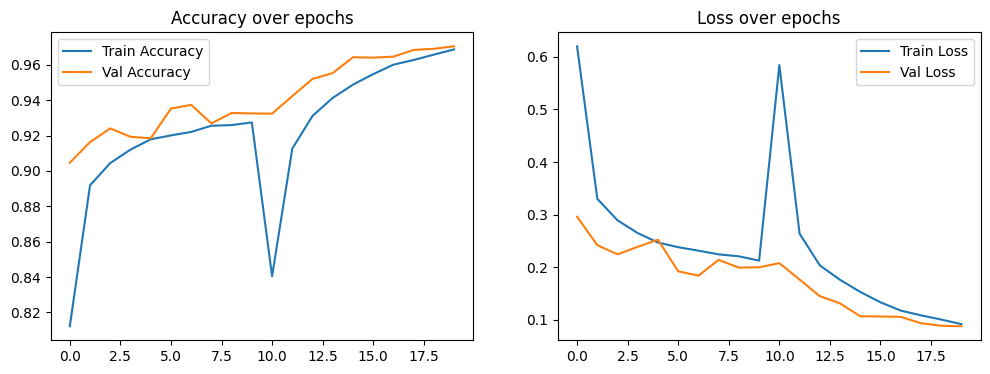

Training curves saved to training_results.png


In [ ]:
acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]
loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.legend()
plt.title("Accuracy over epochs")

plt.subplot(1, 2, 2)
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")
plt.legend()
plt.title("Loss over epochs")

plt.savefig("training_results.png")
plt.show()
print("Training curves saved to training_results.png")
